# 1. Import libraries and load the dataset

In [29]:
import sys
from pathlib import Path

# Find the project root containing pyproject.toml
root = Path.cwd()
while root.name and not (root / 'pyproject.toml').exists():
    root = root.parent

if str(root) not in sys.path:
    sys.path.append(str(root))

import pandas as pd
from configs.config import RAW_DIR


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load data
train = pd.read_csv(RAW_DIR / 'train.csv')
train['date'] = pd.to_datetime(train['date'])
print(f"Data shape: {train.shape}")
print(f"Date range: {train['date'].min()} to {train['date'].max()}")


Data shape: (3000888, 6)
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00


## Missing Dates Verification

Check if `train.csv` is completely missing records for any calendar dates (globally missing dates) before reindexing.

In [31]:
# Compare full calendar range with distinct dates in train.csv to find globally missing dates

full_date_range = pd.date_range(start=train['date'].min(), end=train['date'].max(), freq='D')
actual_dates = pd.DatetimeIndex(train['date'].unique())
missing_dates = full_date_range.difference(actual_dates)

print(f"Full calendar range: {full_date_range.min().date()} to {full_date_range.max().date()} ({len(full_date_range)} days)")
print(f"Actual distinct dates in train.csv: {len(actual_dates)}")
print(f"Number of globally missing dates: {len(missing_dates)}\n")

if len(missing_dates) > 0:
    missing_df = pd.DataFrame({
        'date': missing_dates,
        'day_name': missing_dates.day_name()
    })
    print("List of globally missing dates (no records in train.csv):")
    print(missing_df.to_string(index=False))
else:
    print("No globally missing dates found.")


Full calendar range: 2013-01-01 to 2017-08-15 (1688 days)
Actual distinct dates in train.csv: 1684
Number of globally missing dates: 4

List of globally missing dates (no records in train.csv):
      date  day_name
2013-12-25 Wednesday
2014-12-25  Thursday
2015-12-25    Friday
2016-12-25    Sunday


## Reindexing daily_sales

* **Method Correction**: Reindex the daily sales series to a full calendar range. Globally missing dates (Dec 25th of each year) are filled with 0, and flagged with an `is_reindexed_zero` column.
* **Assumption**: Dec 25th is assumed to be a store-wide holiday closure, hence sales are set to 0.

In [32]:
daily_sales_raw = train.groupby('date')['sales'].sum()
daily_sales_raw = daily_sales_raw.reindex(full_date_range)

# Flag reindex-filled days to distinguish them from actual zero sales days.
is_reindexed_zero = daily_sales_raw.isna()
daily_sales_raw = daily_sales_raw.fillna(0.0)

daily_sales = daily_sales_raw.reset_index()
daily_sales.columns = ['date', 'sales']
daily_sales['is_reindexed_zero'] = is_reindexed_zero.values

# Sales_capped: ONLY used for plotting "Daily Total Sales" to prevent outliers

cap_value = daily_sales['sales'].quantile(0.99)
daily_sales['sales_capped'] = daily_sales['sales'].clip(upper=cap_value)

daily_sales['year'] = daily_sales['date'].dt.year
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['quarter'] = daily_sales['date'].dt.quarter
daily_sales['day_of_week'] = daily_sales['date'].dt.dayofweek
daily_sales['week'] = daily_sales['date'].dt.isocalendar().week

print(f"daily_sales reindexed: {len(daily_sales)} rows (was {train['date'].nunique()} distinct dates before reindex)")
print(f"Rows filled by reindex (is_reindexed_zero=True): {daily_sales['is_reindexed_zero'].sum()}")
print(daily_sales.loc[daily_sales['is_reindexed_zero'], ['date', 'sales', 'is_reindexed_zero']])


daily_sales reindexed: 1688 rows (was 1684 distinct dates before reindex)
Rows filled by reindex (is_reindexed_zero=True): 4
           date  sales  is_reindexed_zero
358  2013-12-25    0.0               True
723  2014-12-25    0.0               True
1088 2015-12-25    0.0               True
1454 2016-12-25    0.0               True


# 2. Data aggregation

### Data Aggregation

* **Method Correction**: Shifted all aggregations from `sales_capped` to raw `sales`.
* **CAGR Correction**: Normalized 2017 growth using actual observed days (`avg_daily_sales`), correcting the original calculation which compared raw totals for 2017 (a partial year) against 2013.

In [33]:
# Monthly aggregation (using raw sales, NOT sales_capped)
monthly_sales = daily_sales.groupby([daily_sales['date'].dt.to_period('M')])['sales'].agg([
    ('total_sales', 'sum'),
    ('avg_sales', 'mean'),
    ('std_sales', 'std')
]).reset_index()
monthly_sales['date'] = monthly_sales['date'].dt.to_timestamp()

# Quarterly aggregation
quarterly_sales = daily_sales.groupby([daily_sales['date'].dt.to_period('Q')])['sales'].agg([
    ('total_sales', 'sum'),
    ('avg_sales', 'mean')
]).reset_index()
quarterly_sales['date'] = quarterly_sales['date'].dt.to_timestamp()

# Yearly aggregation: sum + actual number of days in the year (reindexed, no 365/366 assumption)
yearly_sales = daily_sales.groupby('year')['sales'].agg([
    ('total_sales', 'sum'),
    ('avg_sales', 'mean')
]).reset_index()
days_per_year = daily_sales.groupby('year').size().rename('num_days')
yearly_sales = yearly_sales.merge(days_per_year, on='year')
yearly_sales['avg_daily_sales'] = yearly_sales['total_sales'] / yearly_sales['num_days']

# Growth rates
monthly_sales['mom_growth'] = monthly_sales['total_sales'].pct_change() * 100
# YoY growth calculated on avg_daily_sales (normalized by actual days), not raw total
yearly_sales['yoy_growth'] = yearly_sales['avg_daily_sales'].pct_change() * 100

print("Actual observed days per year :")
print(yearly_sales[['year', 'num_days', 'total_sales', 'avg_daily_sales']])
print("\nMonthly Sales Summary:")
print(monthly_sales.head())
print("\nYearly Growth (based on normalized avg_daily_sales, not raw total):")
print(yearly_sales)


Actual observed days per year :
   year  num_days   total_sales  avg_daily_sales
0  2013       365  1.404190e+08    384709.627177
1  2014       365  2.094742e+08    573902.044662
2  2015       365  2.408801e+08    659945.481246
3  2016       366  2.886545e+08    788673.559983
4  2017       227  1.942171e+08    855581.799001

Monthly Sales Summary:
        date   total_sales      avg_sales      std_sales  mom_growth
0 2013-01-01  1.032762e+07  333149.185062  100236.429008         NaN
1 2013-02-01  9.658960e+06  344962.849194   71232.006925   -6.474528
2 2013-03-01  1.142850e+07  368661.194758   88307.558055   18.320164
3 2013-04-01  1.099346e+07  366448.824600   75913.184475   -3.806557
4 2013-05-01  1.159770e+07  374119.484098   82202.776404    5.496350

Yearly Growth (based on normalized avg_daily_sales, not raw total):
   year   total_sales      avg_sales  num_days  avg_daily_sales  yoy_growth
0  2013  1.404190e+08  384709.627177       365    384709.627177         NaN
1  2014  2.0947

# 3. Visualization

## Overall Trend



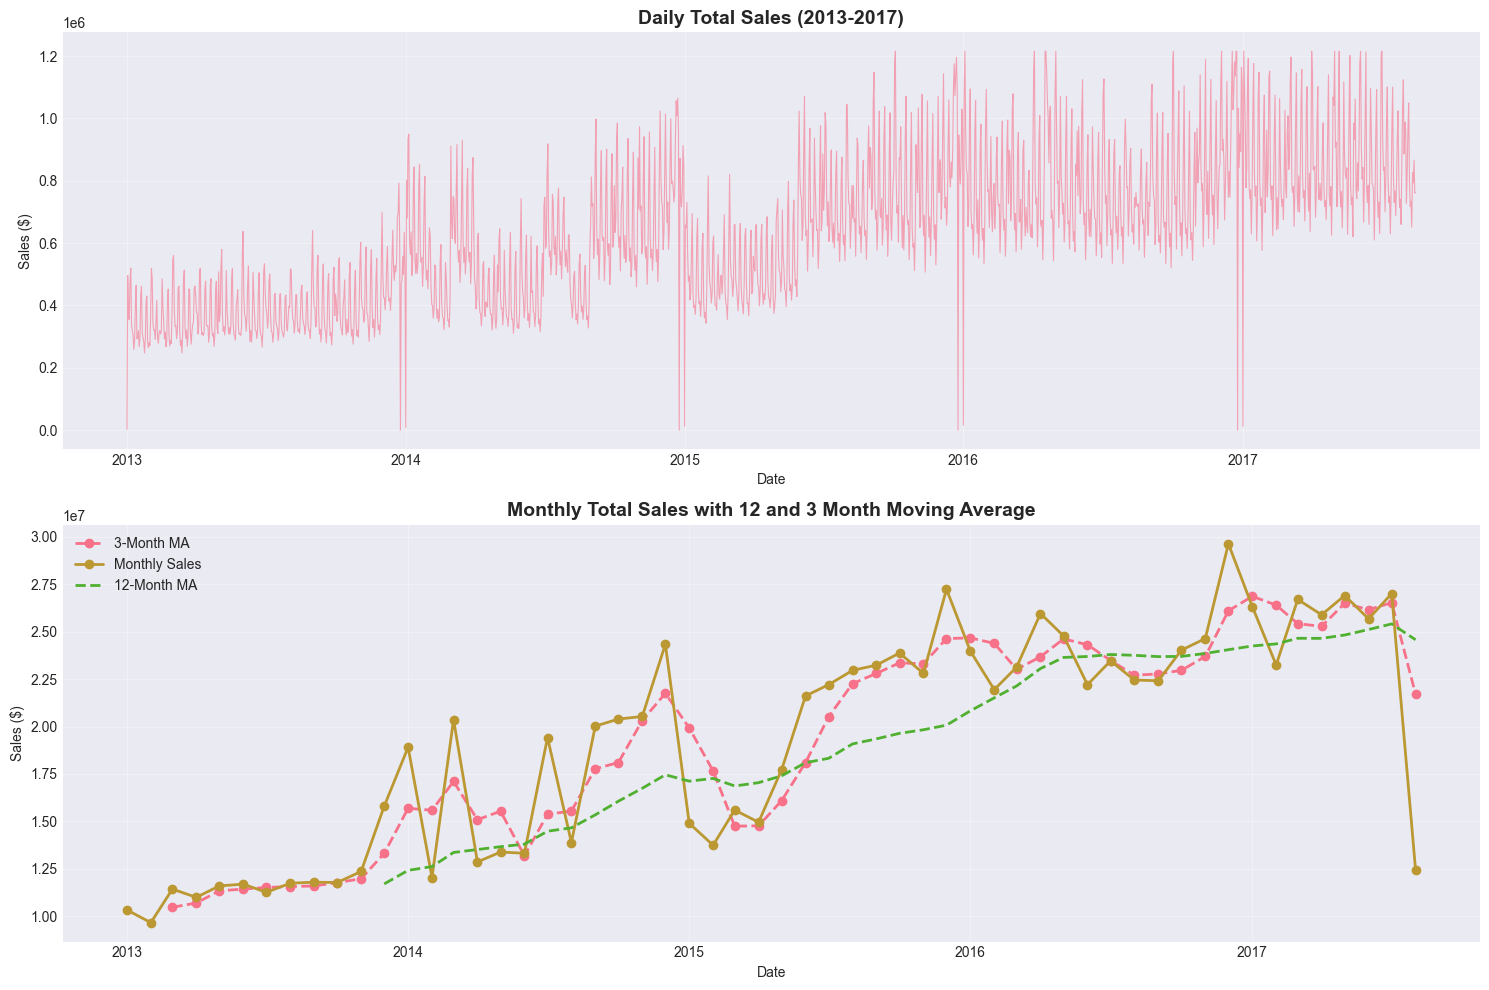

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(15,10))

# Daily sales trend - only this subplot uses sales_capped (for plotting, not computation)
axes[0].plot(daily_sales['date'], daily_sales['sales_capped'], alpha=0.6, linewidth=0.8)
axes[0].set_title('Daily Total Sales (2013-2017)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales ($)')
axes[0].grid(True, alpha=0.3)

# Monthly sales with moving average (monthly_sales calculated on raw sales)
axes[1].plot(monthly_sales['date'], monthly_sales['total_sales'].rolling(3).mean(),
             linewidth=2, linestyle='--', label='3-Month MA', marker='o')
axes[1].set_title('Monthly Total Sales with 3-Month Moving Average', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Sales ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
# Monthly sales with moving average (MA=12)
axes[1].plot(monthly_sales['date'], monthly_sales['total_sales'], marker='o', linewidth=2, label='Monthly Sales')
axes[1].plot(monthly_sales['date'], monthly_sales['total_sales'].rolling(12).mean(),
             linewidth=2, linestyle='--', label='12-Month MA')
axes[1].set_title('Monthly Total Sales with 12 and 3 Month Moving Average', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Sales ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


## Seasonal Decomposition

* **Method Correction**: Decomposition runs on raw reindexed `sales` instead of capped sales.
* **Model Change**: Switched from multiplicative to additive model to handle zero sales on Dec 25th (introduced by reindexing).

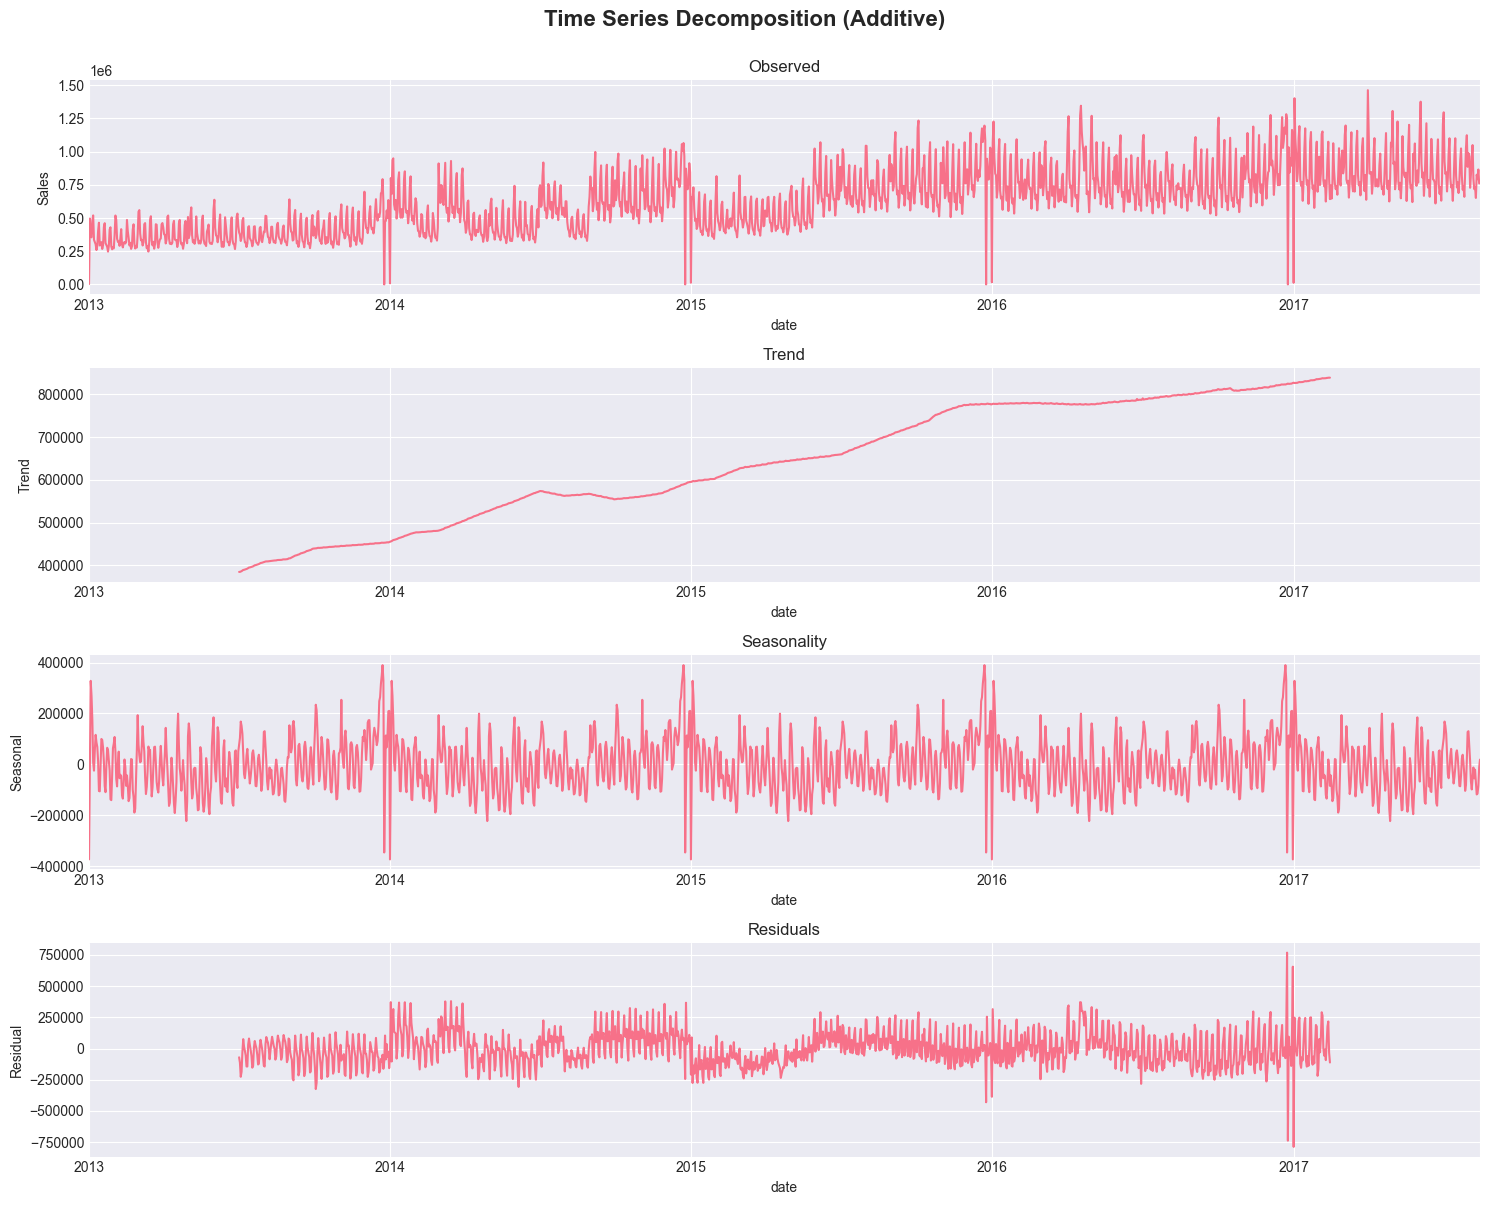

In [35]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily_ts = daily_sales.set_index('date')['sales']
# Additive model: handles zero sales on Dec 25th from reindexing (multiplicative fails with zero)
decomposition = seasonal_decompose(daily_ts, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(15,12))

decomposition.observed.plot(ax=axes[0], title='Observed')
axes[0].set_ylabel('Sales')

decomposition.trend.plot(ax=axes[1], title='Trend')
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
axes[2].set_ylabel('Seasonal')

decomposition.resid.plot(ax=axes[3], title='Residuals')
axes[3].set_ylabel('Residual')

plt.suptitle('Time Series Decomposition (Additive)', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()


## Outlier Detection (Residual-based)

* **Method Correction**: Replaced the 99th percentile threshold (tautology that always flags exactly 1% of data) with a robust MAD-based threshold on residuals: $|residual - median| > 3 \times 1.4826 \times MAD$. This detects both positive and negative anomalies.
* **Verification**: Verify if the 2016-04-16 earthquake in Ecuador is successfully flagged.

In [36]:
resid = decomposition.resid.dropna()
median_resid = resid.median()
mad_resid = (resid - median_resid).abs().median()
# 1.4826 = consistency constant for MAD to estimate standard deviation
threshold = 3 * 1.4826 * mad_resid

outlier_mask = (resid - median_resid).abs() > threshold
outlier_dates = resid[outlier_mask].index

outlier_detail = daily_sales.set_index('date').loc[outlier_dates, ['sales']].copy()
outlier_detail['day_name'] = outlier_detail.index.day_name()
outlier_detail['residual'] = resid[outlier_mask]
outlier_detail = outlier_detail.sort_index()

outlier_count = len(outlier_detail)
print(f"Outlier count (residual-based, 2-sided): {outlier_count} / {len(resid)} days with residuals ({outlier_count/len(resid)*100:.2f}%)")
print(outlier_detail.to_string())

# Test case: verify if 2016-04-16 earthquake (known anomaly) is flagged
earthquake_date = pd.Timestamp('2016-04-16')
is_earthquake_flagged = earthquake_date in outlier_detail.index
print(f"\nTest case - 2016-04-16 (Ecuador earthquake) flagged as outlier: {is_earthquake_flagged}")
if earthquake_date in daily_sales.set_index('date').index:
    eq_sales = daily_sales.set_index('date').loc[earthquake_date, 'sales']
    print(f"  Actual sales on that day: {eq_sales:,.0f}")


Outlier count (residual-based, 2-sided): 12 / 1324 days with residuals (0.91%)
                   sales  day_name       residual
date                                             
2014-01-02  8.010112e+05  Thursday  371617.753494
2014-01-12  8.446336e+05    Sunday  368526.156978
2014-01-19  8.517353e+05    Sunday  370789.087092
2014-03-09  9.161176e+05    Sunday  377452.479546
2014-03-16  9.298085e+05    Sunday  379627.868831
2015-12-25  0.000000e+00    Friday -430956.777586
2016-04-17  1.271834e+06    Sunday  371841.426816
2016-04-18  1.345921e+06    Monday  369941.358891
2016-12-24  1.246838e+06  Saturday  768678.772661
2016-12-25  0.000000e+00    Sunday -738933.169990
2016-12-31  1.109013e+06  Saturday  655915.034043
2017-01-01  1.208250e+04    Sunday -788659.022380

Test case - 2016-04-16 (Ecuador earthquake) flagged as outlier: False
  Actual sales on that day: 862,121


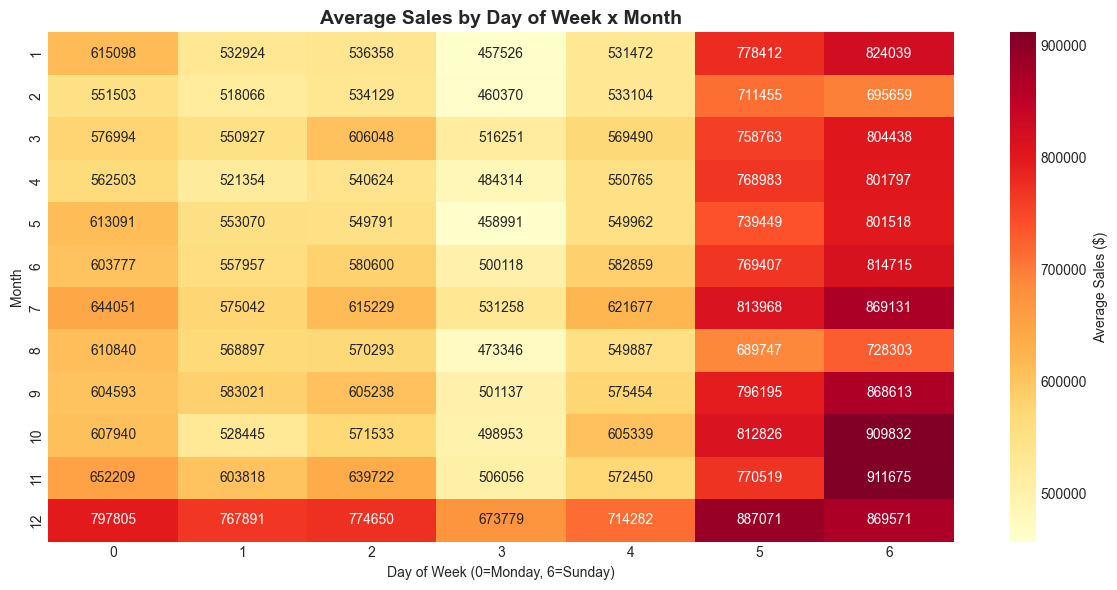

In [37]:
# Day of week x Month heatmap (using raw sales, not sales_capped)

pivot_data = daily_sales.groupby(['month', 'day_of_week'])['sales'].mean().unstack()

plt.figure(figsize=(12,6))
sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Average Sales ($)'})
plt.title('Average Sales by Day of Week x Month', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Month')
plt.tight_layout()
plt.show()


## Year over Year Comparison

<Figure size 1400x600 with 0 Axes>

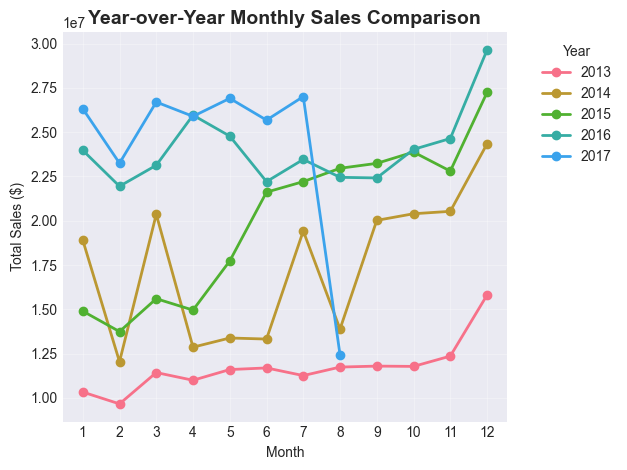

In [38]:
# Monthly sales by year (using raw sales, not sales_capped)
monthly_by_year = daily_sales.groupby(['year', 'month'])['sales'].sum().unstack(level=0)

plt.figure(figsize=(14, 6))
monthly_by_year.plot(marker='o', linewidth=2)
plt.title('Year-over-Year Monthly Sales Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(range(1, 13))
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Distribution Analysis

Plots (histogram, box plots by year/day of week, and zero sales analysis) now use raw sales. Zero sales analysis distinguishes between actual zero sales days and reindex-filled days (Dec 25th).

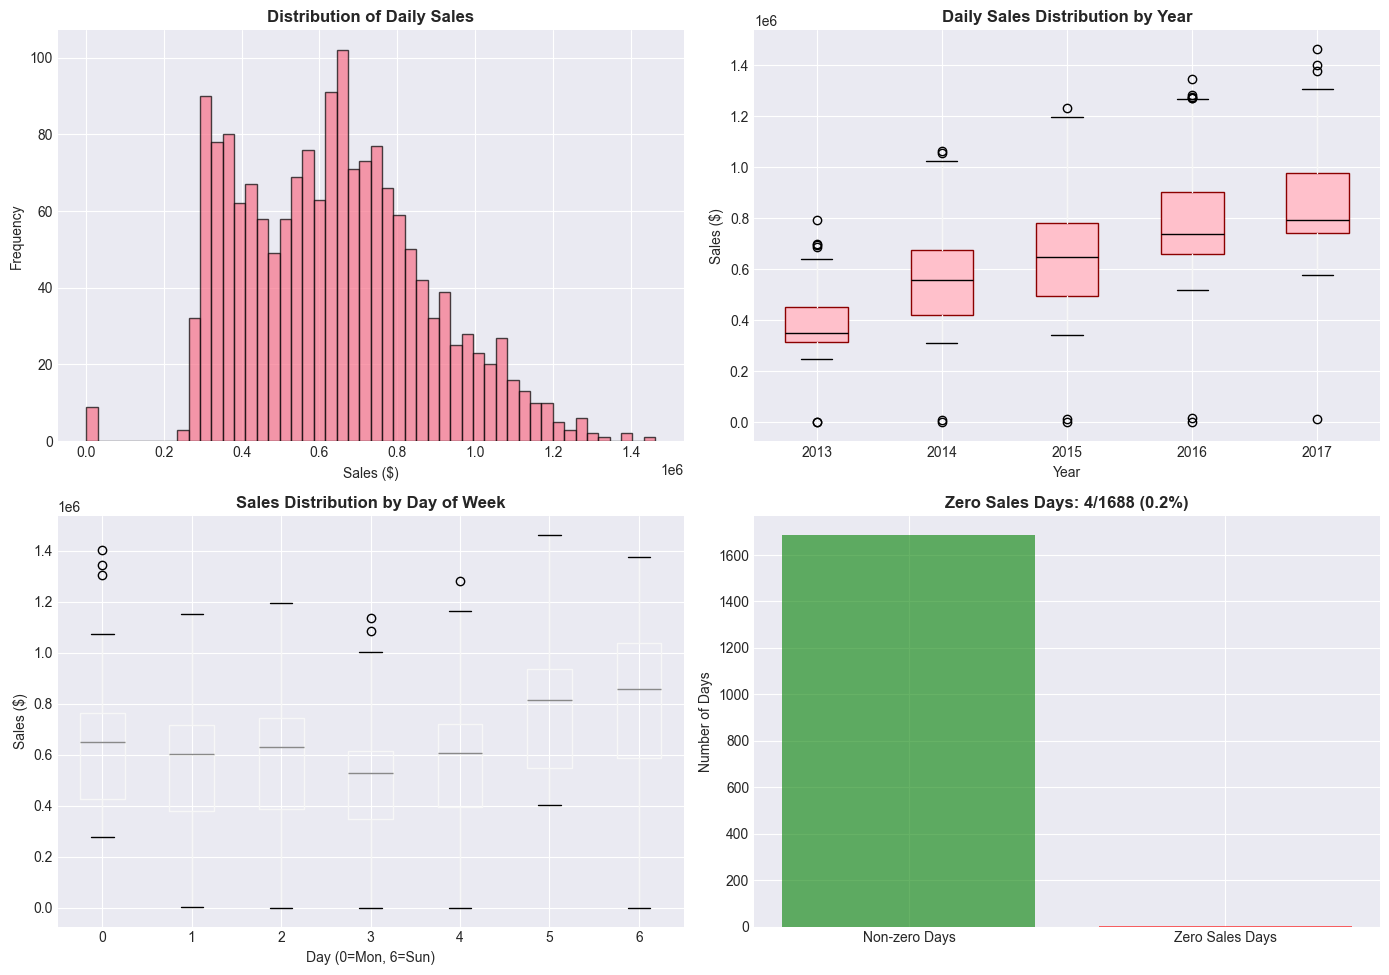

Out of 4 zero-sales days: 4 are reindex-filled days (Dec 25th), and 0 days are actual zero-sales days in the raw data.


In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram (using raw sales, not capped)
axes[0, 0].hist(daily_sales['sales'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Daily Sales', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Sales ($)')
axes[0, 0].set_ylabel('Frequency')

# Box plot by year
daily_sales.boxplot(column='sales', by='year', ax=axes[0, 1],
                    patch_artist=True,
                    boxprops=dict(facecolor='pink', color='darkred'),
                    medianprops=dict(color='black'))
axes[0, 1].set_title('Daily Sales Distribution by Year', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Sales ($)')
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

# Day of week box plot
daily_sales.boxplot(column='sales', by='day_of_week', ax=axes[1, 0],)
axes[1, 0].set_title('Sales Distribution by Day of Week', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Day (0=Mon, 6=Sun)')
axes[1, 0].set_ylabel('Sales ($)')

# Zero sales analysis (distinguish reindex-fill vs actual zero sales)
zero_sales_daily = (daily_sales['sales'] == 0).sum()
total_days = len(daily_sales)
axes[1, 1].bar(['Non-zero Days', 'Zero Sales Days'],
               [total_days - zero_sales_daily, zero_sales_daily],
               color=['green', 'red'], alpha=0.6)
axes[1, 1].set_title(f'Zero Sales Days: {zero_sales_daily}/{total_days} ({zero_sales_daily/total_days*100:.1f}%)',
                     fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Number of Days')

plt.suptitle('')  # Remove auto-generated title
plt.tight_layout()
plt.show()

num_reindexed_zero = daily_sales['is_reindexed_zero'].sum()
print(f"Out of {zero_sales_daily} zero-sales days: {num_reindexed_zero} are reindex-filled days (Dec 25th), "
      f"and {zero_sales_daily - num_reindexed_zero} days are actual zero-sales days in the raw data.")


# 4. Metric Summary

### Summary of Key Metrics

Metrics are re-calculated using raw sales, normalized for actual observed days (CAGR), and using robust residual-based outlier detection.

In [40]:
print("="*60)
print("KEY FINDINGS - OVERALL SALES TRENDS")
print("="*60)

monthly_avg = daily_sales.groupby('month')['sales'].mean()
quarterly_avg = daily_sales.groupby('quarter')['sales'].mean()

# Overall growth 
y2013 = yearly_sales[yearly_sales['year'] == 2013].iloc[0]
y2017 = yearly_sales[yearly_sales['year'] == 2017].iloc[0]
cagr = ((y2017['avg_daily_sales'] / y2013['avg_daily_sales']) ** (1/4) - 1) * 100

print("\n1. OVERALL GROWTH:")
print(f"   2013: {y2013['num_days']:.0f} actual days, avg_daily_sales=${y2013['avg_daily_sales']:,.0f}")
print(f"   2017: {y2017['num_days']:.0f} actual days (PARTIAL YEAR, data only up to 2017-08-15), avg_daily_sales=${y2017['avg_daily_sales']:,.0f}")
print(f"   CAGR (on avg_daily_sales normalized by actual days): {cagr:.2f}%")

# Seasonality
print("\n2. SEASONALITY PATTERNS:")
peak_month = monthly_avg.idxmax()
low_month = monthly_avg.idxmin()
print(f"   Peak month: {peak_month} (Avg: ${monthly_avg[peak_month]:,.0f}/day)")
print(f"   Lowest month: {low_month} (Avg: ${monthly_avg[low_month]:,.0f}/day)")

peak_quarter = quarterly_avg.idxmax()
print(f"   Peak quarter: Q{peak_quarter}")

# Day of week
dow_avg = daily_sales.groupby('day_of_week')['sales'].mean()
peak_dow = dow_avg.idxmax()
low_dow = dow_avg.idxmin()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
print(f"   Best day: {days[peak_dow]} (Avg: ${dow_avg[peak_dow]:,.0f})")
print(f"   Slowest day: {days[low_dow]} (Avg: ${dow_avg[low_dow]:,.0f})")

# Volatility (using raw sales, not capped)
print("\n3. VOLATILITY:")
print(f"   Daily sales std dev: ${daily_sales['sales'].std():,.0f}")
print(f"   Coefficient of variation: {(daily_sales['sales'].std() / daily_sales['sales'].mean()) * 100:.2f}%")

# Data quality
print("\n4. DATA CHARACTERISTICS:")
zero_pct = (train['sales'] == 0).sum() / len(train) * 100
print(f"   Zero sales records (store-product-day level): {zero_pct:.2f}% of all combinations")
print(f"   Zero total-sales days (after reindexing): {zero_sales_daily}/{total_days} ({zero_sales_daily/total_days*100:.2f}%), "
      f"of which {num_reindexed_zero} are reindex-filled")
print(f"   Outliers detected (residual-based, 2-sided): {outlier_count} days ({outlier_count/len(resid)*100:.2f}%)")


KEY FINDINGS - OVERALL SALES TRENDS

1. OVERALL GROWTH:
   2013: 365 actual days, avg_daily_sales=$384,710
   2017: 227 actual days (PARTIAL YEAR, data only up to 2017-08-15), avg_daily_sales=$855,582
   CAGR (on avg_daily_sales normalized by actual days): 22.12%

2. SEASONALITY PATTERNS:
   Peak month: 12 (Avg: $782,483/day)
   Lowest month: 2 (Avg: $571,895/day)
   Peak quarter: Q4
   Best day: Sunday (Avg: $821,794)
   Slowest day: Thursday (Avg: $503,173)

3. VOLATILITY:
   Daily sales std dev: $236,177
   Coefficient of variation: 37.13%

4. DATA CHARACTERISTICS:
   Zero sales records (store-product-day level): 31.30% of all combinations
   Zero total-sales days (after reindexing): 4/1688 (0.24%), of which 4 are reindex-filled
   Outliers detected (residual-based, 2-sided): 12 days (0.91%)
